In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
from classy import Class
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
import math
basedir = os.path.abspath('./')
gdmdir = os.path.join('../gdm_files')

import num2tex
#from matplotlib import rc
import pandas as pd

font = {'size'   : 16, 'family':'STIXGeneral'}
axislabelfontsize='large'
#matplotlib.rc('font', **font)
#matplotlib.mathtext.rcParams['legend.fontsize']='medium'

Parameter Choice:

Cosmological Constant:

$h = 0.6732117$

$\Omega_{cdm} = 0.12038$

$\Omega_{fld} = \Omega_{cdm}/h^2$

$\Omega_{b} = 0.02238280$

$\tau_{reio}=0.05430842$

$A_s = 2.100549e-09$

$n_s = 0.9660499$

$Y_{He} = 0.2454006$

CLASS Parameters:

a_ini_over_a_today_default = 3e-8

start_large_k_at_tau_h_over_tau_k = 0.05

z_max_pk = 5e7       # highest redshift involved

z_max_rec = 1e6

k_per_decade = 250     # number of k values, controls final resolution

k_min_tau0 = .1       # this value controls the minimum k value in the figure (it is k_min * tau0)

P_k_max_inv_Mpc =5   # this value is directly the maximum k value in the figure in Mpc

tau_num_early = 4200   # number of conformal time values before recombination, controls final resolution

tau_num_late = 250     # number of conformal time values after recombination, controls final resolution

tau_ini = 0.01         # first value of conformal time in Mpc

WZDR Model Paramters:

$\Omega_{idm} = 0.00001$ (adjusted $\Omega_{cdm} = 0.12037$)

$N_{wzdr} = 0.6$

$log_{10}{z_t} = 4$

$\Gamma_{0,wzdr} = 1.631329e-07$

rg_wzdr = 1.14285714286$

qsize_wzdr = 10000
                    
qmax_wzdr = 200



Detailed explanation is in https://www.overleaf.com/read/grckhnpkvmns#1a1fc3.

For WZDR model, \
Equation for adiabatic sound speed:
* $ c_{d\rm{,st}}^2 = \frac{(1/3)\delta_{\nu}\rho_{\nu}}{\delta_{\rm{CDM}}\rho_{\rm{CDM}}+\delta_{\nu}\rho_{\nu}} $
* $ c_{d}^2 = \frac{c_{d\rm{,st}}^2 (\delta_{\rm{CDM}}\rho_{\rm{CDM}}+\delta_{\nu}\rho_{\nu})+c_{d\rm{,wzdr}}^2 \delta_{\rm{wzdr}}\rho_{\rm{wzdr}}}{\delta_{\rm{CDM}}\rho_{\rm{CDM}}+\delta_{\nu}\rho_{\nu}+\delta_{\rm{wzdr}}\rho_{\rm{wzdr}}+\delta_{\rm{IDM}}\rho_{\rm{IDM}}} $

Equation for velocity perturbation:
* $\theta_{d} = \frac{\rho_{\rm{CDM}}\theta_{\rm{CDM}}(1+\displaystyle w_{\rm{CDM}})+\rho_{\nu}\theta_{\nu}(1+\displaystyle w_{\nu})+\rho_{\rm{wzdr}}\theta_{\rm{wzdr}}(1+\displaystyle w_{\rm{wzdr}})+\rho_{\rm{IDM}}\theta_{\rm{IDM}}(1+\displaystyle w_{\rm{IDM}})}{\rho_{\rm{CDM}}(1+\displaystyle w_{\rm{CDM}})+\rho_{\nu}(1+\displaystyle w_{\nu})+\rho_{\rm{wzdr}}(1+\displaystyle w_{\rm{wzdr}})+\rho_{\rm{IDM}}(1+\displaystyle w_{\rm{IDM}})}$

Equation for perturbation:
* $\delta_{d} = \frac{\rho_{\rm{CDM}}\delta_{\rm{CDM}}+\rho_{\nu}\delta_{\nu}+\rho_{\rm{wzdr}}\delta_{\rm{wzdr}}+\rho_{\rm{IDM}}\delta_{\rm{IDM}}}{\rho_{\rm{CDM}}+\rho_{\nu}+\rho_{\rm{wzdr}}+\rho_{\rm{IDM}}}$

Equation for effective sound speed:
* $c_{d\rm{,eff}}^2 = \frac{k^2c_{d}^2\delta_d+3c_{d\rm{,ad}}^2\frac{\dot{a}}{a}(1+\displaystyle w_d)\theta_d}{k^2\delta_d+3\frac{\dot{a}}{a}(1+\displaystyle w_d)\theta_d}$

For Lambda-CDM model, \
Equation for adiabatic sound speed:
* $c_{d}^2 = \frac{(1/3)\delta_{\nu}\rho_{\nu}}{\delta_{\rm{CDM}}\rho_{\rm{CDM}}+\delta_{\nu}\rho_{\nu}}$

Equation for velocity perturbation:
* $\theta_{d} = \frac{\rho_{\rm{CDM}}\theta_{\rm{CDM}}(1+\displaystyle w_{\rm{CDM}})+\rho_{\nu}\theta_{\nu}(1+\displaystyle w_{\nu})}{\rho_{\rm{CDM}}(1+\displaystyle w_{\rm{CDM}})+\rho_{\nu}(1+\displaystyle w_{\nu})}$

Equation for perturbation:
* $\delta_{d} = \frac{\rho_{\rm{CDM}}\delta_{\rm{CDM}}+\rho_{\nu}\delta_{\nu}}{\rho_{\rm{CDM}}+\rho_{\nu}}$

Equation for effective sound speed:
* $c_{d\rm{,eff}}^2 = \frac{k^2c_{d}^2\delta_d+3c_{d\rm{,ad}}^2\frac{\dot{a}}{a}(1+\displaystyle w_d)\theta_d}{k^2\delta_d+3\frac{\dot{a}}{a}(1+\displaystyle w_d)\theta_d}$

In [2]:
k_cede = np.loadtxt('kval_frac_0.1.csv')
a_cede = np.loadtxt('aval_frac_0.1.csv')
cs_2_cede = np.loadtxt('sound_speed_frac_0.1.csv')
k_arb = np.loadtxt('kval_arb.csv')
a_arb = np.loadtxt('aval_arb.csv')
cs_2_arb = np.loadtxt('sound_speed_arb.csv')

In [3]:
# Plot fractional/absolute difference between normal transition redshift (zt = 4) and high transition redshift (zt = 10)
absolute_difference_4 = cs_2_wzdr_4-cs_2_wzdr_10
fractional_difference_4 = (cs_2_wzdr_4-cs_2_wzdr_10)/cs_2_wzdr_10

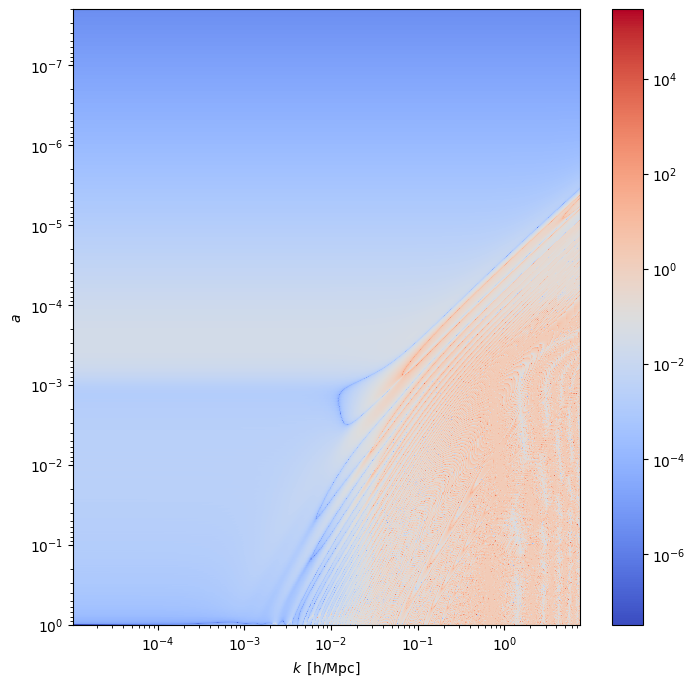

In [4]:
# Absolute Fractional difference
fig = plt.figure(figsize=(18,8)) 
cs2h = fig.add_subplot(121)
  
fig_cs2h = cs2h.pcolormesh(k_wzdr,a_wzdr,abs(fractional_difference_4),cmap='coolwarm',norm='log')#, vmin=1e-4, vmax = 1e2) #,shading='gouraud')
# fig_cs2h = cs2h.pcolormesh(k_wzdr,a_wzdr,fractional_difference_4,cmap='coolwarm',vmin=-5, vmax = 5) #,shading='gouraud'
#rect = patches.Rectangle((kl, al), kr-kl, ar-al, linewidth=1, edgecolor='r', facecolor='none')abs(fractional_difference_4)
#fig_cs2h = cs2h.pcolormesh(K,T,cs2_2d)
#cs2h.add_patch(rect)

#cs2h.set_xlim(k_arb[0],k_arb[-1])
#cs2h.set_ylim([3.04e-8,1.e0])
cs2h.set_xscale('log')
cs2h.set_yscale('log')
cs2h.set_xlabel(r'$k  \,\,\, \mathrm{[h/Mpc]}$')
cs2h.set_ylabel(r'$a$')
cs2h.invert_yaxis()
fig.colorbar(fig_cs2h)
#+fine_dcs2(2999,1464,10,10,coarse_dcs2(10,10,ij_pairs,vals),'kick')

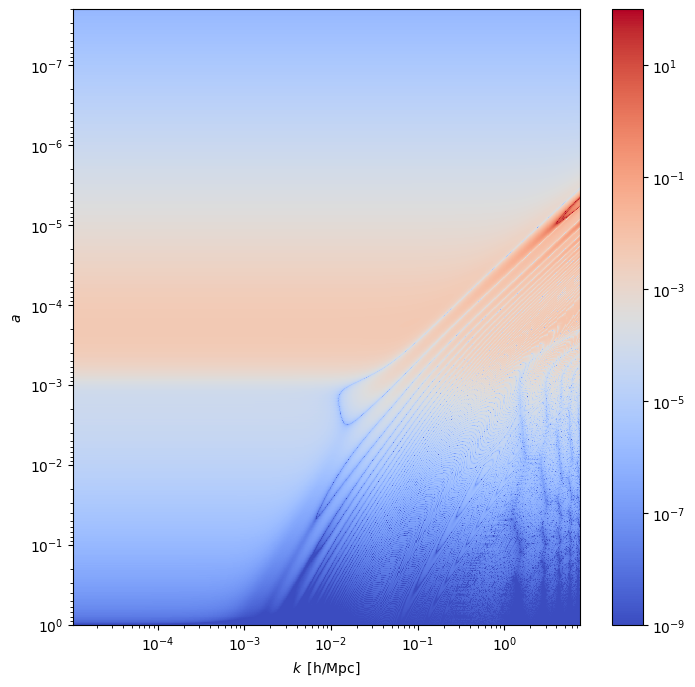

In [5]:
# Absolute Absolutte difference
fig = plt.figure(figsize=(18,8)) 
cs2h = fig.add_subplot(121)
  
fig_cs2h = cs2h.pcolormesh(k_wzdr,a_wzdr,abs(absolute_difference_4),cmap='coolwarm',norm='log', vmin=1e-9, vmax = 1e2) #,shading='gouraud')

cs2h.set_xscale('log')
cs2h.set_yscale('log')
cs2h.set_xlabel(r'$k  \,\,\, \mathrm{[h/Mpc]}$')
cs2h.set_ylabel(r'$a$')
cs2h.invert_yaxis()
fig.colorbar(fig_cs2h)

In [3]:
# Plotting the fractional/absolute difference between the WZDR model and the Lambda-CDM model.
fractional_difference_4 = (cs_2_cede-cs_2_arb)/cs_2_arb
absolute_difference_4 = cs_2_cede-cs_2_arb

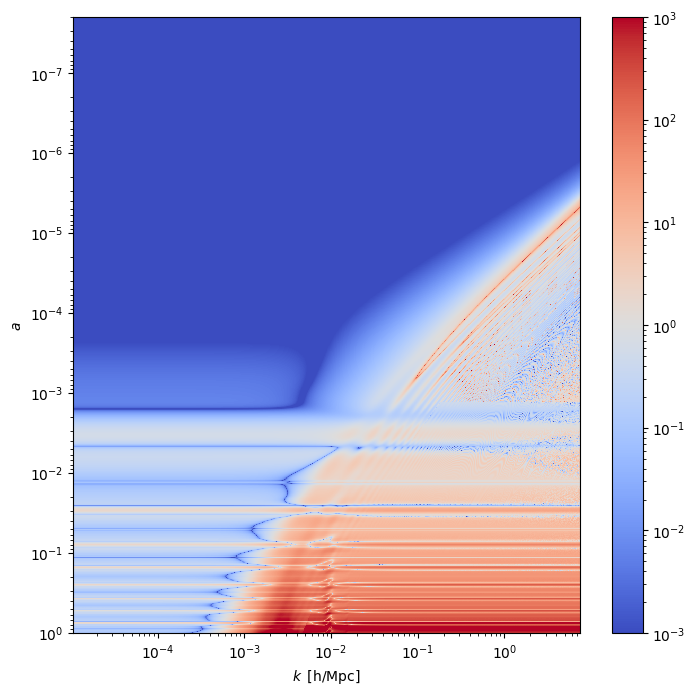

In [4]:
# Fractional difference
fig = plt.figure(figsize=(18,8)) 
cs2h = fig.add_subplot(121)
  
fig_cs2h = cs2h.pcolormesh(k_arb,a_arb,abs(fractional_difference_4),cmap='coolwarm',norm='log',vmax =1e3, vmin = 1e-3) #,shading='gouraud')
#rect = patches.Rectangle((kl, al), kr-kl, ar-al, linewidth=1, edgecolor='r', facecolor='none')abs(fractional_difference_4)
#fig_cs2h = cs2h.pcolormesh(K,T,cs2_2d)
#cs2h.add_patch(rect)

#cs2h.set_xlim(k_arb[0],k_arb[-1])
#cs2h.set_ylim([3.04e-8,1.e0])
cs2h.set_xscale('log')
cs2h.set_yscale('log')
cs2h.set_xlabel(r'$k  \,\,\, \mathrm{[h/Mpc]}$')
cs2h.set_ylabel(r'$a$')
cs2h.invert_yaxis()
fig.colorbar(fig_cs2h)
#+fine_dcs2(2999,1464,10,10,coarse_dcs2(10,10,ij_pairs,vals),'kick')

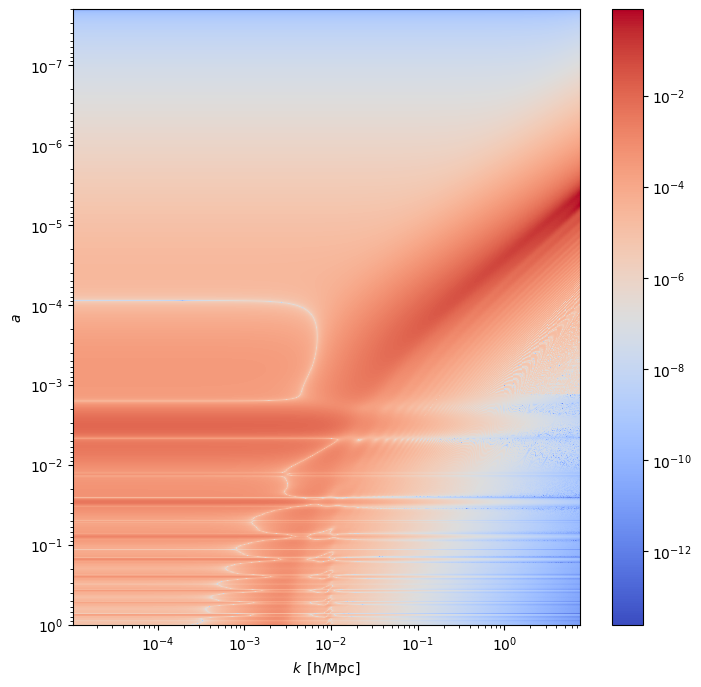

In [5]:
# Absolute Absolutte difference
fig = plt.figure(figsize=(18,8)) 
cs2h = fig.add_subplot(121)

fig_cs2h = cs2h.pcolormesh(k_arb,a_arb,abs(absolute_difference_4),cmap='coolwarm',norm='log') #,shading='gouraud')

cs2h.set_xscale('log')
cs2h.set_yscale('log')
cs2h.set_xlabel(r'$k  \,\,\, \mathrm{[h/Mpc]}$')
cs2h.set_ylabel(r'$a$')
cs2h.invert_yaxis()
fig.colorbar(fig_cs2h)

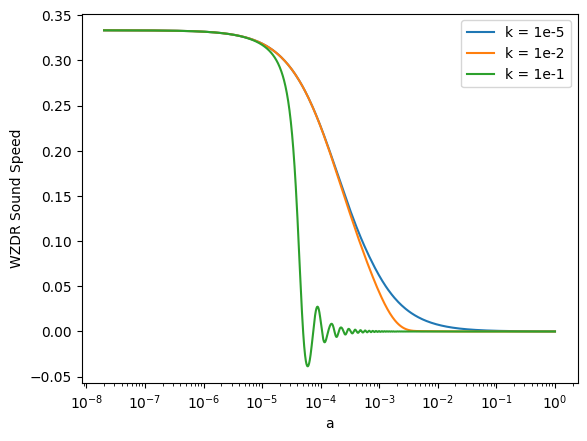

In [15]:
plt.plot(a_arb.T[0],cs_2_wzdr_4.T[0],label='k = 1e-5')
plt.plot(a_arb.T[800],cs_2_wzdr_4.T[800],label='k = 1e-2')
plt.plot(a_arb.T[1200],cs_2_wzdr_4.T[1200],label='k = 1e-1')
plt.xscale('log')
plt.xlabel('a')
plt.ylabel('WZDR Sound Speed')
plt.legend()

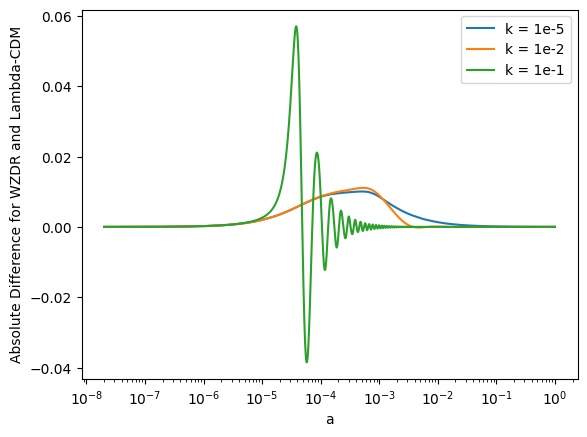

In [14]:
plt.plot(a_arb.T[0],absolute_difference_4.T[0],label='k = 1e-5')
plt.plot(a_arb.T[800],absolute_difference_4.T[800],label='k = 1e-2')
plt.plot(a_arb.T[1200],absolute_difference_4.T[1200],label='k = 1e-1')
plt.xscale('log')
plt.xlabel('a')
plt.ylabel('Absolute Difference for WZDR and Lambda-CDM')
plt.legend()